In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/AI_ML_Projects 2026/Data/Student_Performance_Prediction/student_performance.csv"
)

df.head()

,Study_Hours,Attendance,Assignments,Quiz_Score,Exam_Marks
0,7,92,1,68,73
1,4,99,6,77,78
2,8,71,5,42,76
3,5,95,3,55,72
4,7,63,7,69,79


In [ ]:
# Features and Target

X = df[["Study_Hours", "Attendance", "Assignments", "Quiz_Score"]]
y = df["Exam_Marks"]

print(X.head())
print(y.head())

   Study_Hours  Attendance  Assignments  Quiz_Score
0            7          92            1          68
1            4          99            6          77
2            8          71            5          42
3            5          95            3          55
4            7          63            7          69
0    73
1    78
2    76
3    72
4    79
Name: Exam_Marks, dtype: int64


In [ ]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 800
Testing Samples: 200


In [ ]:
model = joblib.load(
    "/content/drive/MyDrive/AI_ML_Projects 2026/Models/Student_Performance_Prediction/student_performance_model.pkl"
)

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² Score :", round(r2, 3))
print("MAE      :", round(mae, 3))
print("MSE      :", round(mse, 3))

R² Score : 0.957
MAE      : 2.715
MSE      : 9.933


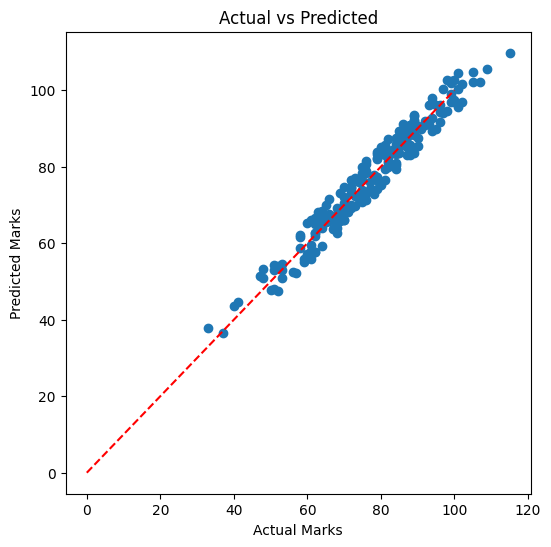

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")

plt.plot([0,100],[0,100],'r--')

plt.show()